
## Hyperparameter Tuning, Dropout, Early Stopping & Checkpoints

### Overview
This notebook covers:
1. **Problem Statement**: Binary classification on synthetic dataset
2. **Data Preprocessing**: Normalization and splitting
3. **ANN Model**: Building Neural Networks
4. **Hyperparameter Tuning**: Using GridSearchCV
5. **Dropout**: Regularization technique
6. **Early Stopping**: Prevent overfitting
7. **Model Checkpoints**: Save best models
8. **Training & Evaluation**: Complete pipeline

## Step 1: Import Required Libraries

In [2]:
# Core Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve

# TensorFlow & Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from scikeras.wrappers import KerasClassifier


# Set Seeds for Reproducibility
np.random.seed(42)
tf.random.set_seed(42)



## Step 2: Problem Statement & Data Generation

**Problem**: Predict customer churn (Binary Classification)
- **Input**: Customer features (20 features)
- **Output**: Churn (0 or 1)
- **Samples**: 1000 training samples

Dataset Shape: (1000, 20)
Labels Shape: (1000,)
Class Distribution:
  - Class 0 (No Churn): 502 samples
  - Class 1 (Churn): 498 samples


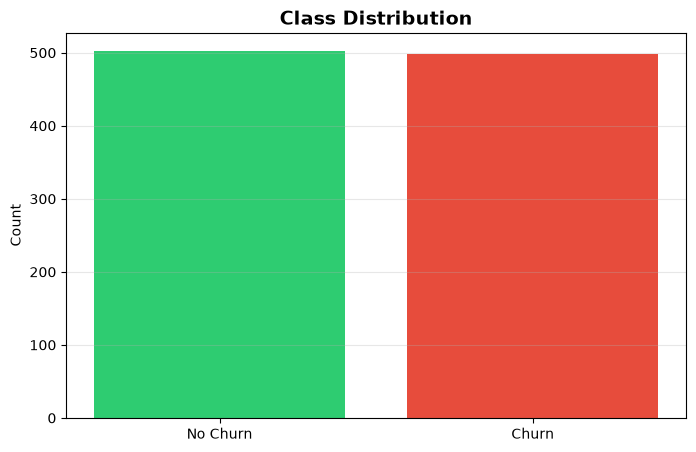

In [3]:
# Generate synthetic dataset
from sklearn.datasets import make_classification

# Create dataset
X, y = make_classification(
    n_samples=1000,           # Number of samples
    n_features=20,            # Number of features
    n_informative=15,         # Informative features
    n_redundant=5,            # Redundant features
    n_classes=2,              # Binary classification
    random_state=42
)

print(f"Dataset Shape: {X.shape}")
print(f"Labels Shape: {y.shape}")
print(f"Class Distribution:")
print(f"  - Class 0 (No Churn): {(y == 0).sum()} samples")
print(f"  - Class 1 (Churn): {(y == 1).sum()} samples")

# Visualize class distribution
plt.figure(figsize=(8, 5))
plt.bar(['No Churn', 'Churn'], [sum(y == 0), sum(y == 1)], color=['#2ecc71', '#e74c3c'])
plt.title('Class Distribution', fontsize=14, fontweight='bold')
plt.ylabel('Count')
plt.grid(axis='y', alpha=0.3)
plt.show()

## Step 3: Data Preprocessing

### Key Concepts:
- **Train-Test Split**: Divide data into training and testing sets
- **Standardization**: Scale features to have mean=0 and std=1
- **Why**: Neural networks converge faster with normalized data

In [4]:
# Step 3.1: Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,        # 20% for testing
    random_state=42,
    stratify=y            # Maintain class distribution
)

print(f"Training Set: {X_train.shape}")
print(f"Testing Set: {X_test.shape}")

# Step 3.2: Further split training data for validation
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train,
    test_size=0.2,        # 20% of training for validation
    random_state=42,
    stratify=y_train
)

print(f"\nFinal Split:")
print(f"  - Training: {X_train.shape}")
print(f"  - Validation: {X_val.shape}")
print(f"  - Testing: {X_test.shape}")

Training Set: (800, 20)
Testing Set: (200, 20)

Final Split:
  - Training: (640, 20)
  - Validation: (160, 20)
  - Testing: (200, 20)


In [5]:
# Step 3.3: Standardize the data
# Why: Neural networks prefer normalized inputs (0 mean, unit variance)

scaler = StandardScaler()

# Fit scaler on training data only (avoid data leakage)
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Data Standardization:")
print(f"Training Data - Mean: {X_train_scaled.mean():.4f}, Std: {X_train_scaled.std():.4f}")
print(f"Validation Data - Mean: {X_val_scaled.mean():.4f}, Std: {X_val_scaled.std():.4f}")
print(f"Testing Data - Mean: {X_test_scaled.mean():.4f}, Std: {X_test_scaled.std():.4f}")
print("\n✓ Data preprocessing completed!")

Data Standardization:
Training Data - Mean: -0.0000, Std: 1.0000
Validation Data - Mean: -0.0134, Std: 0.9911
Testing Data - Mean: 0.0090, Std: 1.0170

✓ Data preprocessing completed!


## Step 4: Build ANN Model (Without Hyperparameter Tuning First)

### Model Architecture Concepts:
1. **Input Layer**: 20 features
2. **Hidden Layers**: Dense layers with activation functions
3. **Activation Functions**: ReLU for hidden layers, Sigmoid for output
4. **Output Layer**: 1 neuron with sigmoid (binary classification)
5. **Loss Function**: Binary crossentropy
6. **Optimizer**: Adam (adaptive learning rate)

In [6]:
def create_model(
    learning_rate=0.001,
    dropout_rate=0.2,
    hidden_units=128
):

    model = keras.Sequential([
        keras.layers.Input(shape=(X_train_scaled.shape[1],)),
        keras.layers.Dense(hidden_units, activation="relu"),
        keras.layers.Dropout(dropout_rate),

        keras.layers.Dense(64, activation="relu"),
        keras.layers.Dropout(dropout_rate),

        keras.layers.Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=learning_rate
        ),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            keras.metrics.AUC(name="auc")
        ]
    )

    return model

## Step 5: Understanding Key Concepts

### 5.1 DROPOUT
- **What**: Randomly deactivates neurons during training
- **Why**: Prevents co-adaptation, reduces overfitting
- **Effect**: Network learns more robust features
- **Testing**: Dropout is disabled during evaluation

### 5.2 EARLY STOPPING
- **What**: Stops training when validation metric stops improving
- **Why**: Prevents overfitting, saves computational resources
- **Monitor**: Usually validation loss or accuracy
- **Parameters**: patience (epochs to wait), min_delta (minimum improvement)

### 5.3 MODEL CHECKPOINTS
- **What**: Saves the model when validation metric improves
- **Why**: Keeps the best model throughout training
- **Modes**: Save best, save latest, save at intervals
- **Usage**: Restore best model after training completes

In [7]:
print(y_train.shape)
print(y_val.shape)
print(y_test.shape)

(640,)
(160,)
(200,)


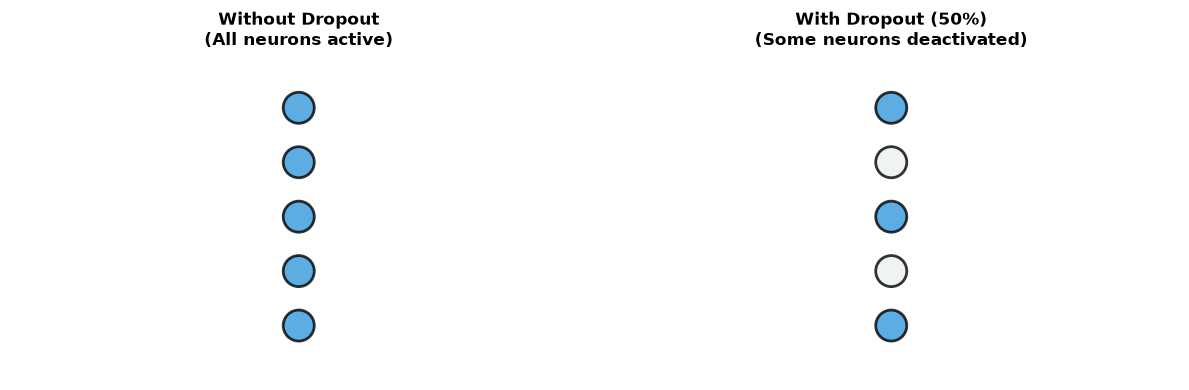

Blue circles = Active neurons
Gray circles = Deactivated neurons (during training only)


In [8]:
# Visual explanation of Dropout
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Without dropout
ax = axes[0]
nodes = np.array([[1, 2, 3, 4, 5]] * 3).T
colors_no_dropout = ['#3498db'] * 5
ax.scatter([1]*5, range(1, 6), s=500, c=colors_no_dropout, alpha=0.8, edgecolors='black', linewidth=2)
ax.set_xlim(0.5, 1.5)
ax.set_ylim(0, 6)
ax.set_title('Without Dropout\n(All neurons active)', fontsize=12, fontweight='bold')
ax.axis('off')

# With dropout
ax = axes[1]
colors_dropout = ['#3498db', '#ecf0f1', '#3498db', '#ecf0f1', '#3498db']  # Gray = dropped
ax.scatter([1]*5, range(1, 6), s=500, c=colors_dropout, alpha=0.8, edgecolors='black', linewidth=2)
ax.set_xlim(0.5, 1.5)
ax.set_ylim(0, 6)
ax.set_title('With Dropout (50%)\n(Some neurons deactivated)', fontsize=12, fontweight='bold')
ax.axis('off')

plt.tight_layout()
plt.show()

print("Blue circles = Active neurons")
print("Gray circles = Deactivated neurons (during training only)")

## Step 6: Setup Callbacks (Early Stopping & Checkpoints)

In [9]:
# Create callbacks for training

# 1. Early Stopping Callback
early_stopping = EarlyStopping(
    monitor='val_loss',           # Monitor validation loss
    patience=10,                  # Stop if no improvement for 10 epochs
    min_delta=0.001,              # Minimum improvement threshold
    restore_best_weights=True,    # Restore weights from best epoch
    verbose=1
)

# 2. Model Checkpoint Callback
baseline_checkpoint_path = "baseline_best_model.keras"
checkpoint = ModelCheckpoint(
    filepath=baseline_checkpoint_path,     # File to save model
    monitor='val_loss',           # Monitor validation loss
    save_best_only=True,          # Save only when val_loss improves
    mode='min',                   # Lower is better for loss
    verbose=1
)

# List of callbacks
callbacks = [early_stopping, checkpoint]

print("✓ Baseline callbacks configured")
print(f"Checkpoint path: {baseline_checkpoint_path}")

✓ Baseline callbacks configured
Checkpoint path: baseline_best_model.keras


## Step 7: Train Initial Model (Non-tuned)

In [10]:
# Create and train initial model
model_baseline = create_model(
    learning_rate=0.001,
    dropout_rate=0.2,
    hidden_units=128
)

# Train model
history = model_baseline.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=28,                  # Maximum epochs
    batch_size=32,               # Samples per batch
    callbacks=callbacks,
    verbose=0                    # Set to 1 to see progress
)

print(f"Training completed!")
print(f"Total epochs trained: {len(history.history['loss'])}")


Epoch 1: val_loss improved from None to 0.52947, saving model to baseline_best_model.keras

Epoch 1: finished saving model to baseline_best_model.keras

Epoch 2: val_loss improved from 0.52947 to 0.40929, saving model to baseline_best_model.keras

Epoch 2: finished saving model to baseline_best_model.keras

Epoch 3: val_loss improved from 0.40929 to 0.32904, saving model to baseline_best_model.keras

Epoch 3: finished saving model to baseline_best_model.keras

Epoch 4: val_loss improved from 0.32904 to 0.28143, saving model to baseline_best_model.keras

Epoch 4: finished saving model to baseline_best_model.keras

Epoch 5: val_loss improved from 0.28143 to 0.25221, saving model to baseline_best_model.keras

Epoch 5: finished saving model to baseline_best_model.keras

Epoch 6: val_loss improved from 0.25221 to 0.23114, saving model to baseline_best_model.keras

Epoch 6: finished saving model to baseline_best_model.keras

Epoch 7: val_loss improved from 0.23114 to 0.21792, saving model t

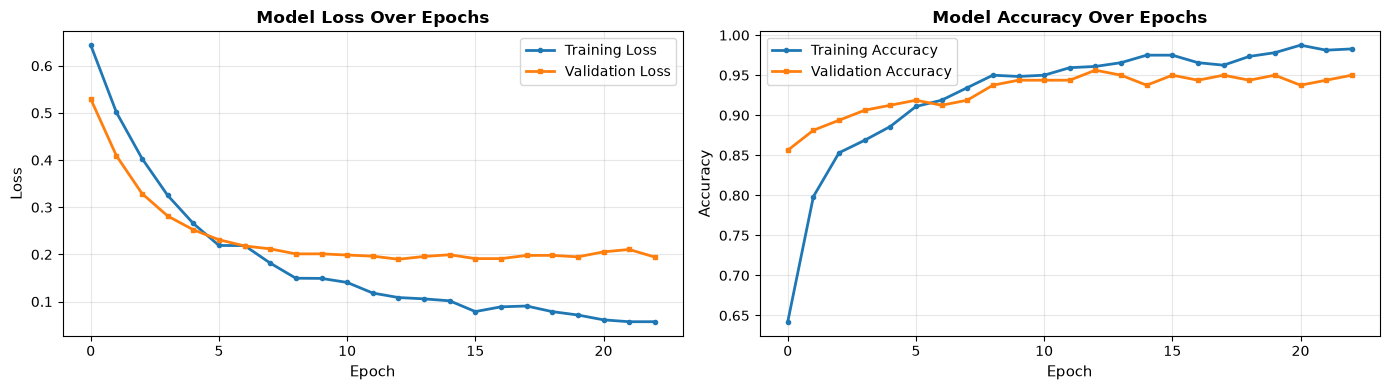


Training Observations:
  - Best Validation Loss: 0.1897
  - Best Validation Accuracy: 0.9563
  - Early stopping triggered at epoch 23


In [11]:
# Visualize training history
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Plot 1: Loss
ax = axes[0]
ax.plot(history.history['loss'], label='Training Loss', linewidth=2, marker='o', markersize=3)
ax.plot(history.history['val_loss'], label='Validation Loss', linewidth=2, marker='s', markersize=3)
ax.set_xlabel('Epoch', fontsize=11)
ax.set_ylabel('Loss', fontsize=11)
ax.set_title('Model Loss Over Epochs', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Accuracy
ax = axes[1]
ax.plot(history.history['accuracy'], label='Training Accuracy', linewidth=2, marker='o', markersize=3)
ax.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2, marker='s', markersize=3)
ax.set_xlabel('Epoch', fontsize=11)
ax.set_ylabel('Accuracy', fontsize=11)
ax.set_title('Model Accuracy Over Epochs', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nTraining Observations:")
print(f"  - Best Validation Loss: {min(history.history['val_loss']):.4f}")
print(f"  - Best Validation Accuracy: {max(history.history['val_accuracy']):.4f}")
print(f"  - Early stopping triggered at epoch {len(history.history['loss'])}")

## Step 8: Hyperparameter Tuning with GridSearchCV

### Key Hyperparameters to Tune:
1. **dense_layers**: Number of hidden layers
2. **dense_units**: Units in each layer
3. **dropout_rate**: Dropout percentage
4. **learning_rate**: Optimizer learning rate
5. **batch_size**: Samples per batch

### Interview Tips:
- Start with broad ranges, then narrow down
- Use cross-validation to avoid overfitting to test set
- Balance between performance and computational cost

In [12]:

#  hyperparameter tuning starts


model_wrapper = KerasClassifier(
    model=create_model,
    epochs=10,
    batch_size=32,
    verbose=0
)
   


param_grid = {

    "model__learning_rate":[0.001,0.0005],

    "model__dropout_rate":[0.2,0.3],

    "model__hidden_units":[64,128],

    "batch_size":[16,32],

    "epochs":[10,20]
}

In [13]:
# Perform Grid Search
print("Starting GridSearchCV...")
print("This may take a few minutes...\n")

grid_search = GridSearchCV(

    estimator=model_wrapper,

    param_grid=param_grid,

    cv=3,

    scoring="accuracy",

    verbose=3,

    n_jobs=1,

    error_score="raise"
)

# Run grid search
grid_search.fit(
    X_train_scaled,
    y_train
)

print("\n✓ GridSearchCV completed!")

Starting GridSearchCV...
This may take a few minutes...

Fitting 3 folds for each of 32 candidates, totalling 96 fits
[CV 1/3] END batch_size=16, epochs=10, model__dropout_rate=0.2, model__hidden_units=64, model__learning_rate=0.001;, score=0.902 total time=   2.4s
[CV 2/3] END batch_size=16, epochs=10, model__dropout_rate=0.2, model__hidden_units=64, model__learning_rate=0.001;, score=0.901 total time=   2.6s
[CV 3/3] END batch_size=16, epochs=10, model__dropout_rate=0.2, model__hidden_units=64, model__learning_rate=0.001;, score=0.911 total time=   2.7s
[CV 1/3] END batch_size=16, epochs=10, model__dropout_rate=0.2, model__hidden_units=64, model__learning_rate=0.0005;, score=0.864 total time=   2.7s
[CV 2/3] END batch_size=16, epochs=10, model__dropout_rate=0.2, model__hidden_units=64, model__learning_rate=0.0005;, score=0.873 total time=   2.7s
[CV 3/3] END batch_size=16, epochs=10, model__dropout_rate=0.2, model__hidden_units=64, model__learning_rate=0.0005;, score=0.897 total time

In [14]:
print(grid_search.best_score_)
print(grid_search.best_params_)

0.9390622029163559
{'batch_size': 16, 'epochs': 20, 'model__dropout_rate': 0.2, 'model__hidden_units': 64, 'model__learning_rate': 0.001}


In [15]:
results_df = pd.DataFrame(grid_search.cv_results_)
results_df.keys()

Index(['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time',
       'param_batch_size', 'param_epochs', 'param_model__dropout_rate',
       'param_model__hidden_units', 'param_model__learning_rate', 'params',
       'split0_test_score', 'split1_test_score', 'split2_test_score',
       'mean_test_score', 'std_test_score', 'rank_test_score'],
      dtype='str')

In [16]:
results_df = pd.DataFrame(grid_search.cv_results_)

results_df = results_df[
[
"param_model__learning_rate",
"param_model__dropout_rate",
"param_model__hidden_units",
"param_batch_size",
"param_epochs",
"mean_test_score",
"std_test_score",
"rank_test_score"
]
]

results_df.sort_values(
"rank_test_score",
inplace=True
)

results_df.head(10)

,param_model__learning_rate,param_model__dropout_rate,param_model__hidden_units,param_batch_size,param_epochs,mean_test_score,std_test_score,rank_test_score
8,0.0010,0.2,64,16,20,0.939062,0.000134,1
14,0.0010,0.3,128,16,20,0.937490,0.012368,2
10,0.0010,0.2,128,16,20,0.931259,0.008771,3
24,0.0010,0.2,64,32,20,0.925000,0.000165,4
2,0.0010,0.2,128,16,10,0.923449,0.010974,5
30,0.0010,0.3,128,32,20,0.923435,0.002300,6
12,0.0010,0.3,64,16,20,0.920305,0.006724,7
26,0.0010,0.2,128,32,20,0.918747,0.002306,8
13,0.0005,0.3,64,16,20,0.909409,0.015719,9
11,0.0005,0.2,128,16,20,0.909394,0.009439,10


## Step 9: Train Final Model with Best Hyperparameters

In [17]:
early_stopping = EarlyStopping(
    monitor='val_loss',           # Monitor validation loss
    patience=10,                  # Stop if no improvement for 10 epochs
    min_delta=0.001,              # Minimum improvement threshold
    restore_best_weights=True,    # Restore weights from best epoch
    verbose=1
)


In [18]:
tuned_checkpoint_path = "tuned_best_model.keras"
tuned_checkpoint = ModelCheckpoint(
    filepath=tuned_checkpoint_path,
    monitor="val_loss",
    save_best_only=True,
)

In [19]:
# Create model with best hyperparameters
best = grid_search.best_params_

final_model = create_model(

    learning_rate=best["model__learning_rate"],

    dropout_rate=best["model__dropout_rate"],

    hidden_units=best["model__hidden_units"]
)

print("Final Model Architecture (with best hyperparameters):")
final_model.summary()

Final Model Architecture (with best hyperparameters):


Model: "sequential_98"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_294 (Dense)               │ (None, 64)             │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_196 (Dropout)           │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_295 (Dense)               │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_197 (Dropout)           │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_296 (Dense)               │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,569 (21.75 KB)

 Trainable params: 5,569 (21.75 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
# Train final model with early stopping and checkpoints
print("\nTraining final model with best hyperparameters...\n")
history = final_model.fit(

    X_train_scaled,

    y_train,

    validation_data=(X_val_scaled,y_val),

    epochs=best["epochs"],

    batch_size=best["batch_size"],

    callbacks=[early_stopping, tuned_checkpoint],

    verbose=1
)

print("✓ Final model training completed!")


Training final model with best hyperparameters...

Epoch 1/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6875 - auc: 0.7549 - loss: 0.6057 - val_accuracy: 0.8188 - val_auc: 0.9016 - val_loss: 0.5033
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8000 - auc: 0.8800 - loss: 0.4793 - val_accuracy: 0.8750 - val_auc: 0.9388 - val_loss: 0.3882
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8297 - auc: 0.9245 - loss: 0.3845 - val_accuracy: 0.8875 - val_auc: 0.9508 - val_loss: 0.3224
Epoch 4/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8578 - auc: 0.9428 - loss: 0.3263 - val_accuracy: 0.8875 - val_auc: 0.9578 - val_loss: 0.2799
Epoch 5/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9000 - auc: 0.9579 - loss: 0.2784 - val_accuracy: 0.8875 - val_auc: 0.9610 - val_loss: 0.2623
Epoch 6/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8891 - auc: 0.9627 - loss: 0.2553 - val_accuracy: 0.9000 - val_auc: 0.9649 - val_loss: 0.2489

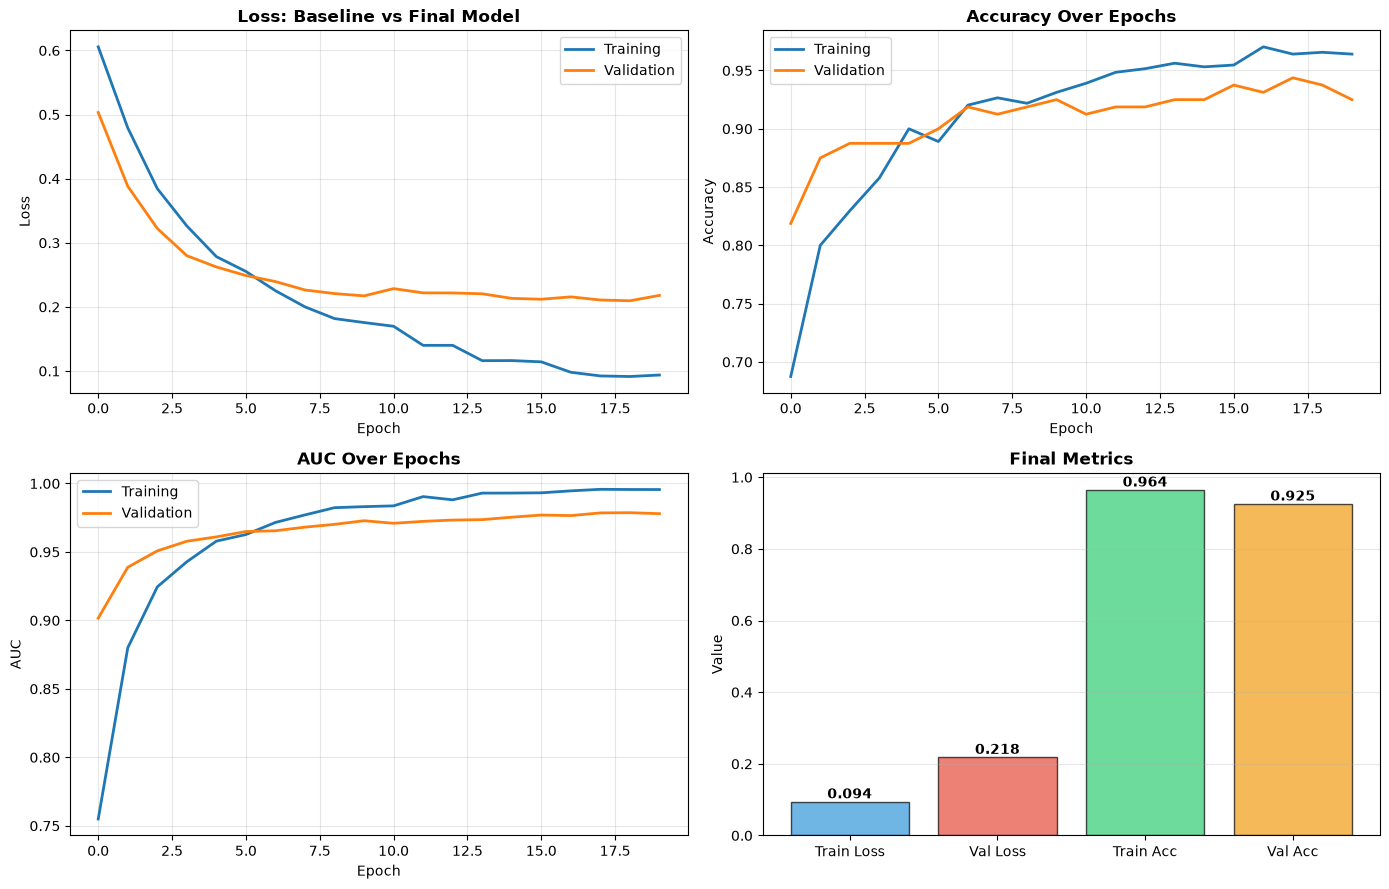

In [21]:
# Plot final model training history
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Loss
ax = axes[0, 0]
ax.plot(history.history['loss'], label='Training', linewidth=2)
ax.plot(history.history['val_loss'], label='Validation', linewidth=2)
ax.set_title('Loss: Baseline vs Final Model', fontsize=12, fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend()
ax.grid(True, alpha=0.3)

# Accuracy
ax = axes[0, 1]
ax.plot(history.history['accuracy'], label='Training', linewidth=2)
ax.plot(history.history['val_accuracy'], label='Validation', linewidth=2)
ax.set_title('Accuracy Over Epochs', fontsize=12, fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy')
ax.legend()
ax.grid(True, alpha=0.3)

# AUC
ax = axes[1, 0]
ax.plot(history.history['auc'], label='Training', linewidth=2)
ax.plot(history.history['val_auc'], label='Validation', linewidth=2)
ax.set_title('AUC Over Epochs', fontsize=12, fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('AUC')
ax.legend()
ax.grid(True, alpha=0.3)

# Comparison of key metrics
ax = axes[1, 1]
metrics = ['Train Loss', 'Val Loss', 'Train Acc', 'Val Acc']
values = [
    history.history['loss'][-1],
    history.history['val_loss'][-1],
    history.history['accuracy'][-1],
    history.history['val_accuracy'][-1]
]
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']
ax.bar(metrics, values, color=colors, alpha=0.7, edgecolor='black')
ax.set_title('Final Metrics', fontsize=12, fontweight='bold')
ax.set_ylabel('Value')
ax.grid(axis='y', alpha=0.3)

for i, v in enumerate(values):
    ax.text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

## Step 10: Load Best Model and Evaluate on Test Set

In [22]:
# Load the best model from checkpoint
best_model = keras.models.load_model('tuned_best_model.keras')

print("Best model loaded from checkpoint!")
print(f"\nModel was saved during training at the epoch with best validation loss")

Best model loaded from checkpoint!

Model was saved during training at the epoch with best validation loss


In [23]:
# Evaluate on test set
test_loss, test_accuracy, test_auc = best_model.evaluate(
    X_test_scaled, y_test,
    verbose=0
)

print("\n" + "="*60)
print("TEST SET EVALUATION")
print("="*60)
print(f"Test Loss:      {test_loss:.4f}")
print(f"Test Accuracy:  {test_accuracy:.4f}")
print(f"Test AUC:       {test_auc:.4f}")
print("="*60)


TEST SET EVALUATION
Test Loss:      0.1660
Test Accuracy:  0.9350
Test AUC:       0.9814


In [24]:
print(best_model.metrics_names)

['loss', 'compile_metrics']


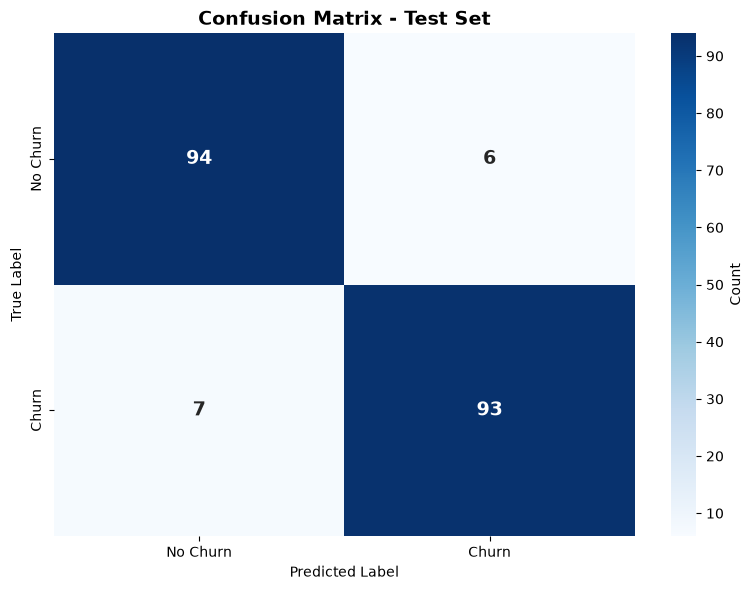


Classification Report:
              precision    recall  f1-score   support

    No Churn       0.93      0.94      0.94       100
       Churn       0.94      0.93      0.93       100

    accuracy                           0.94       200
   macro avg       0.94      0.94      0.93       200
weighted avg       0.94      0.94      0.93       200



In [25]:
# Get predictions
y_pred_proba = best_model.predict(X_test_scaled, verbose=0)
y_pred = (y_pred_proba > 0.5).astype(int).flatten()

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'],
            cbar_kws={'label': 'Count'},
            annot_kws={'fontsize': 14, 'fontweight': 'bold'})
plt.title('Confusion Matrix - Test Set', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

# Print classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, 
                          target_names=['No Churn', 'Churn']))

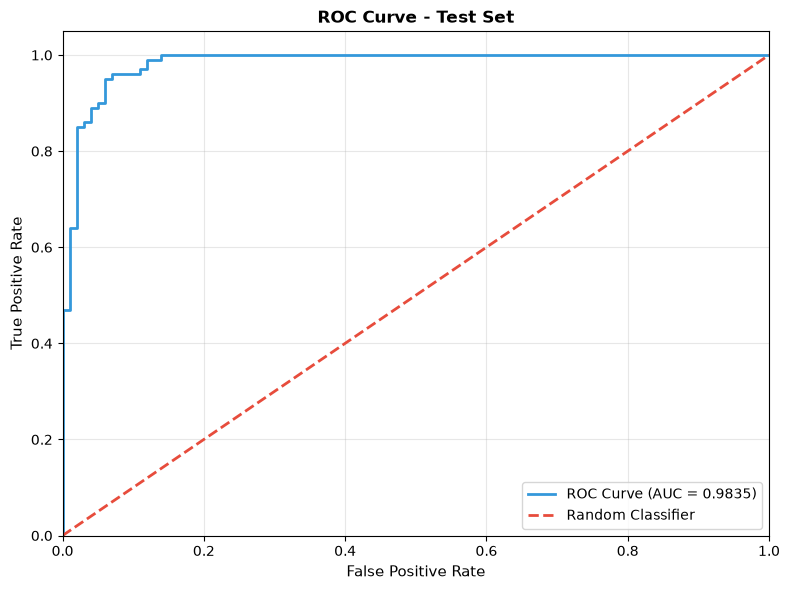

In [26]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = roc_auc_score(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#3498db', lw=2, 
         label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='#e74c3c', lw=2, linestyle='--', 
         label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=11)
plt.ylabel('True Positive Rate', fontsize=11)
plt.title('ROC Curve - Test Set', fontsize=12, fontweight='bold')
plt.legend(loc="lower right", fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Step 11: Model Comparison & Summary

In [27]:
baseline_model = keras.models.load_model("baseline_best_model.keras")
tuned_model = keras.models.load_model("tuned_best_model.keras")

In [28]:
# Compare baseline vs final model
baseline_loss, baseline_acc, baseline_auc = baseline_model.evaluate(
    X_test_scaled, y_test, verbose=0
)

tuned_loss, tuned_acc, tuned_auc = tuned_model.evaluate(
    X_test_scaled, y_test, verbose=0
)

# Create comparison dataframe
comparison = pd.DataFrame({
    'Metric': ['Loss', 'Accuracy', 'AUC'],
    'Baseline Model': [baseline_loss, baseline_acc, baseline_auc],
    'Tuned Model': [tuned_loss, tuned_acc, tuned_auc],
    'Improvement': [
        baseline_loss - tuned_loss,
        tuned_acc - baseline_acc,
        tuned_auc - baseline_auc
    ]
})

print("\n" + "="*70)
print("MODEL COMPARISON (FAIR EVALUATION)")
print("="*70)
print(comparison.to_string(index=False))


MODEL COMPARISON (FAIR EVALUATION)
  Metric  Baseline Model  Tuned Model  Improvement
    Loss        0.177199     0.165983     0.011216
Accuracy        0.925000     0.935000     0.010000
     AUC        0.980150     0.981450     0.001300


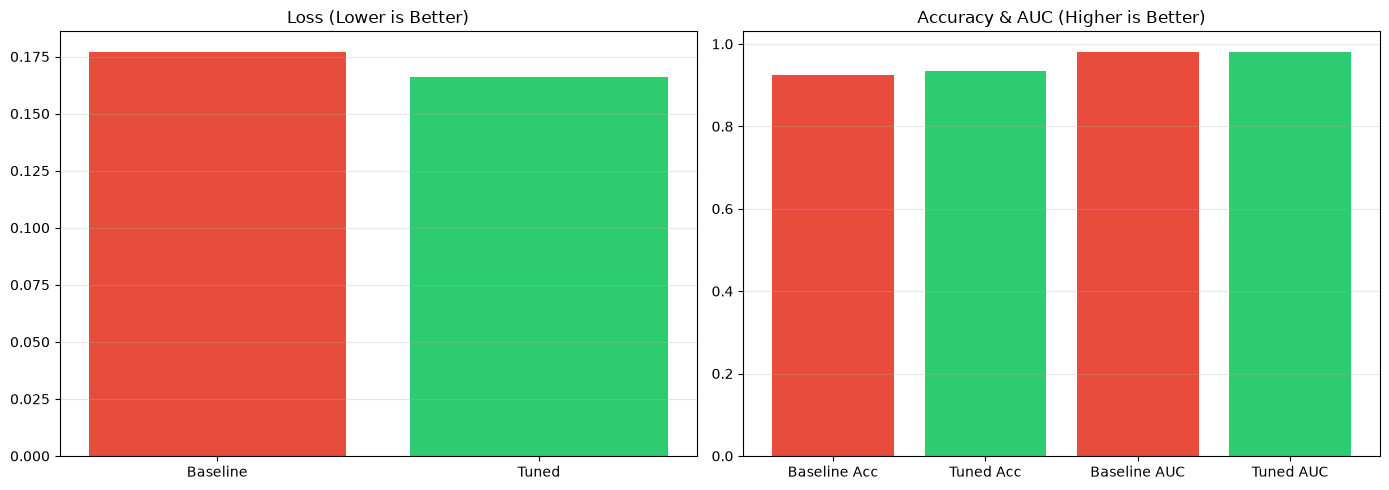

In [29]:
# Visualization of comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Loss (lower is better)
axes[0].bar(['Baseline', 'Tuned'],
            [comparison.loc[0, 'Baseline Model'],
             comparison.loc[0, 'Tuned Model']],
            color=['#e74c3c', '#2ecc71'])

axes[0].set_title("Loss (Lower is Better)")
axes[0].grid(axis='y', alpha=0.3)

# --- Accuracy + AUC (higher is better)
axes[1].bar(['Baseline Acc', 'Tuned Acc',
              'Baseline AUC', 'Tuned AUC'],
             [
                 comparison.loc[1, 'Baseline Model'],
                 comparison.loc[1, 'Tuned Model'],
                 comparison.loc[2, 'Baseline Model'],
                 comparison.loc[2, 'Tuned Model']
             ],
             color=['#e74c3c', '#2ecc71', '#e74c3c', '#2ecc71'])

axes[1].set_title("Accuracy & AUC (Higher is Better)")
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()